# Per-Cluster Model Performance
Breaks test R² and residual distributions down by the 3 management zone clusters.
A cluster the model struggles on signals that zone is driven by something outside the feature set — itself a finding.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

os.makedirs('../img', exist_ok=True)

In [2]:
df = pd.read_pickle('../data/df.pkl')
target_cols = [f'ndvi_anomaly_{w}' for w in range(36, 44)]

leakage_cols = []
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and any(col.endswith(f'_{m}') for m in range(36, 45))]
leakage_cols += [col for col in df.columns if col.startswith('ndvi_smooth_mean') and col not in leakage_cols]
leakage_cols += [col for col in df.columns if (col.startswith('ndvi_smooth_slope_') or col.startswith('ndvi_smooth_std_')) and int(col.rsplit('_', 1)[-1]) >= 36]
leakage_cols += [c for c in ['ndvi_mean','ndvi_cov','ndvi_std','ndvi_mean_norm','ndvi_std_norm','ndvi_cov_norm','health'] if c in df.columns]
leakage_cols += [col for col in df.columns if 'mcari2' in col or 'rendvi' in col]
leakage_cols += [col for col in df.columns if col.endswith('length')]

drop_cols = set(leakage_cols + ['plot_id', 'year'] + target_cols)
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df[target_cols]

# Attach plot_id before split (needed to join cluster labels)
X_with_meta = X.copy()
X_with_meta['_plot_id'] = df['plot_id'].values

X_train, X_tune, y_train, y_tune = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_m, X_tune_m, _, _ = train_test_split(X_with_meta, y, test_size=0.2, random_state=42)
X_train_m, X_test_m, y_train_, y_test = train_test_split(X_train_m, y_train, test_size=0.15, random_state=42)
X_train, X_test = X_train_m.drop(columns=['_plot_id']), X_test_m.drop(columns=['_plot_id'])
test_plot_ids = X_test_m['_plot_id'].values

print(f'Test set: {X_test.shape}, unique plots: {len(np.unique(test_plot_ids))}')

Test set: (4318, 283), unique plots: 2592


In [3]:
# --- Load cluster labels and join to test set ---
df_clustered = pd.read_pickle('df_clustered.pkl')
cluster_lookup = df_clustered.set_index('plot_id')['cluster'].to_dict()
test_clusters = np.array([cluster_lookup.get(pid, -1) for pid in test_plot_ids])

cluster_counts = pd.Series(test_clusters).value_counts().sort_index()
print('Test set cluster distribution:')
print(cluster_counts.to_string())

Test set cluster distribution:
0    1106
1    2048
2    1164


In [4]:
# --- Predict and compute R² per cluster ---
model = joblib.load('models/tree_ensemble.pkl')
y_pred = model.predict(X_test)
y_true = y_test.to_numpy()

overall_r2 = r2_score(y_test, y_pred)
print(f'Overall test R²: {overall_r2:.4f}')
print()

cluster_results = {}
for c in sorted(np.unique(test_clusters)):
    mask = test_clusters == c
    if mask.sum() < 10:
        continue
    r2 = r2_score(y_true[mask], y_pred[mask])
    rmse = mean_squared_error(y_true[mask], y_pred[mask])**0.5
    resid = (y_pred[mask] - y_true[mask]).mean(axis=1)
    cluster_results[c] = {'r2': r2, 'rmse': rmse, 'n': mask.sum(), 'resid': resid}
    print(f'Cluster {c}: n={mask.sum():4d} | R²={r2:.4f} | RMSE={rmse:.6f}')

    per_week = [r2_score(y_true[mask, i], y_pred[mask, i]) for i in range(8)]
    print(f'           per-week R²: {[f"{v:.3f}" for v in per_week]}')

Overall test R²: 0.9320

Cluster 0: n=1106 | R²=0.9563 | RMSE=0.023981
           per-week R²: ['0.975', '0.972', '0.969', '0.964', '0.957', '0.948', '0.935', '0.930']
Cluster 1: n=2048 | R²=0.9169 | RMSE=0.021322
           per-week R²: ['0.951', '0.949', '0.944', '0.936', '0.920', '0.906', '0.877', '0.853']
Cluster 2: n=1164 | R²=0.9041 | RMSE=0.024511
           per-week R²: ['0.940', '0.937', '0.931', '0.923', '0.910', '0.890', '0.862', '0.840']


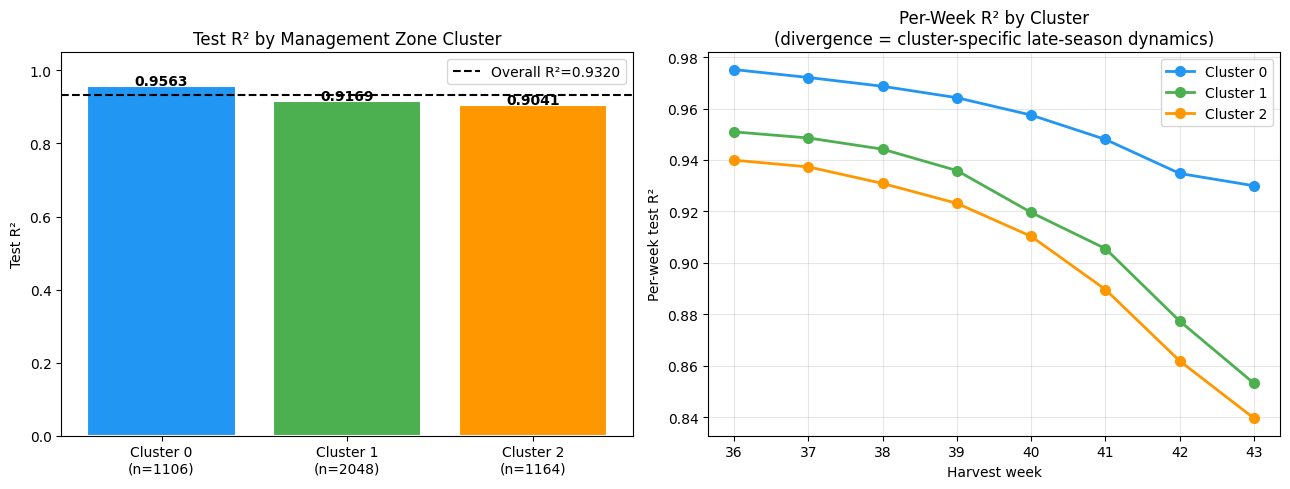

In [5]:
# --- Plot: R² by cluster and per-week breakdown ---
weeks = list(range(36, 44))
cluster_ids = sorted(cluster_results.keys())
cluster_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: overall R² per cluster
ax = axes[0]
r2_vals = [cluster_results[c]['r2'] for c in cluster_ids]
n_vals = [cluster_results[c]['n'] for c in cluster_ids]
bars = ax.bar([f'Cluster {c}\n(n={n_vals[i]})' for i, c in enumerate(cluster_ids)],
              r2_vals,
              color=[cluster_colors[c] for c in cluster_ids],
              edgecolor='white', linewidth=1.5)
ax.axhline(overall_r2, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall R²={overall_r2:.4f}')
for bar, r2 in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{r2:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test R²')
ax.set_ylim(0, 1.05)
ax.set_title('Test R² by Management Zone Cluster')
ax.legend()

# Right: per-week R² curves by cluster
ax2 = axes[1]
for c in cluster_ids:
    mask = test_clusters == c
    per_week = [r2_score(y_true[mask, i], y_pred[mask, i]) for i in range(8)]
    ax2.plot(weeks, per_week, 'o-', color=cluster_colors[c], linewidth=2,
             label=f'Cluster {c}', markersize=7)

ax2.set_xlabel('Harvest week')
ax2.set_ylabel('Per-week test R²')
ax2.set_title('Per-Week R² by Cluster\n(divergence = cluster-specific late-season dynamics)')
ax2.set_xticks(weeks)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../img/cluster_performance.png', dpi=150, bbox_inches='tight')
plt.show()

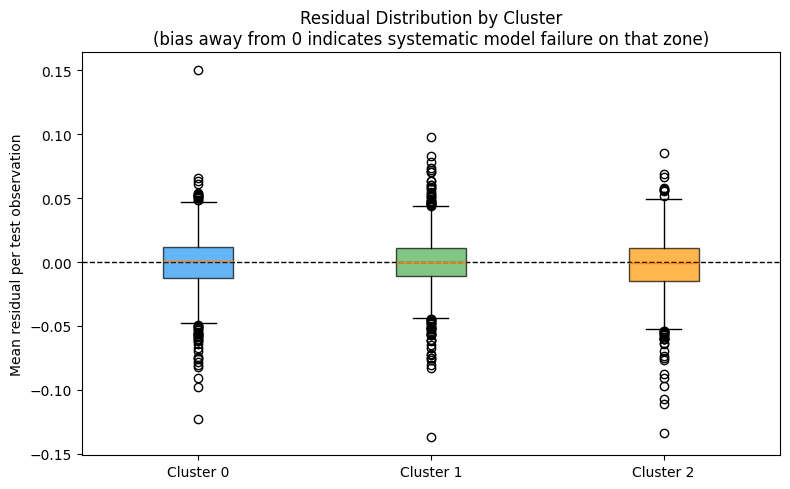

In [6]:
# --- Residual boxplots by cluster ---
fig, ax = plt.subplots(figsize=(8, 5))
resid_by_cluster = [cluster_results[c]['resid'] for c in cluster_ids]

bp = ax.boxplot(resid_by_cluster,
                tick_labels=[f'Cluster {c}' for c in cluster_ids],
                patch_artist=True, notch=False)
for patch, c in zip(bp['boxes'], cluster_ids):
    patch.set_facecolor(cluster_colors[c])
    patch.set_alpha(0.7)

ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Mean residual per test observation')
ax.set_title('Residual Distribution by Cluster\n(bias away from 0 indicates systematic model failure on that zone)')
plt.tight_layout()
plt.savefig('../img/cluster_residuals.png', dpi=150, bbox_inches='tight')
plt.show()